In [1]:
# OPTIONAL KAGGLE BOOTSTRAP
#
# The numerical trainer is CPU-only in the repository by default. On Kaggle
# we can still use the GPU by switching the fitting core to a CuPy backend
# later in the notebook. This cell only makes the workspace layout explicit.
from pathlib import Path
import os
import subprocess

IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ or Path("/kaggle/working").exists()
USE_KAGGLE_GPU_FOR_TRAINING = True
KAGGLE_CUPY_PACKAGE = "cupy-cuda12x"
KAGGLE_REPO_URL = "https://github.com/AlmondSund/MeasurementCalibration.git"
KAGGLE_WORKING_DIR = Path("/kaggle/working")
KAGGLE_REPO_DIR = KAGGLE_WORKING_DIR / "MeasurementCalibration"

if IS_KAGGLE:
    KAGGLE_WORKING_DIR.mkdir(parents=True, exist_ok=True)
    if not KAGGLE_REPO_DIR.exists():
        subprocess.run(
            ["git", "clone", KAGGLE_REPO_URL, str(KAGGLE_REPO_DIR)],
            check=True,
            cwd=KAGGLE_WORKING_DIR,
        )
    os.chdir(KAGGLE_REPO_DIR / "notebooks")

print(
    {
        "cwd": os.getcwd(),
        "is_kaggle": IS_KAGGLE,
        "use_kaggle_gpu_for_training": bool(
            IS_KAGGLE and USE_KAGGLE_GPU_FOR_TRAINING
        ),
        "kaggle_repo_dir": str(KAGGLE_REPO_DIR) if IS_KAGGLE else None,
    }
)


Cloning into '/kaggle/working/MeasurementCalibration'...


{'cwd': '/kaggle/working/MeasurementCalibration/notebooks', 'is_kaggle': True, 'use_kaggle_gpu_for_training': True, 'kaggle_repo_dir': '/kaggle/working/MeasurementCalibration'}


Updating files: 100% (246/246), done.


# Configuration-Conditional Sensor Calibration

This notebook prepares a small offline calibration corpus, fits the current two-level spectral calibration model, stores the resulting artifact, and inspects the learned persistent laws.

The offline objective combines the Gaussian likelihood, campaign-deviation regularization, and optional same-scene auxiliary penalties on the persistent-only corrected spectra. Those extra terms regularize only the deployment-transferable gain and floor laws, so campaign-specific deviations remain training-only nuisance variables.

The key architectural boundary is:

- `campaign_calibration.py` handles repository I/O, metadata parsing, alignment, and campaign diagnostics.
- `spectral_calibration.py` holds the numerical model and optimizer.
- `artifacts.py` persists the fitted result for later deployment.

In [2]:
# Shared workflow configuration lives under ``config/notebook_workflow/``.
# Edit those files instead of maintaining notebook-local campaign or node lists.
NOTEBOOK_WORKFLOW_CONFIG_DIRNAME = "config/notebook_workflow"

In [3]:
from __future__ import annotations

from copy import copy
from dataclasses import dataclass
from pathlib import Path
import os
import shutil
import subprocess
import sys
from tempfile import mkdtemp
import time

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the current notebook cwd."""

    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / "measurement_calibration").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not resolve the repository root from the notebook cwd")


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from measurement_calibration import (
    CalibrationCorpusFitResult,
    CampaignCalibrationState,
    DEFAULT_ARCHIVED_ARTIFACTS_DIR,
    DEFAULT_ARTIFACT_PARAMETERS_FILENAME,
    DEFAULT_CAMPAIGNS_DATA_DIR,
    DEFAULT_PRODUCTION_ARTIFACT_DIR,
    DEFAULT_PRODUCTION_PARAMETERS_FILENAME,
    FileSystemCampaignSensorDataRepository,
    FrequencyBasisConfig,
    PersistentModelConfig,
    TwoLevelCalibrationResult,
    TwoLevelFitConfig,
    archive_artifact_directory,
    evaluate_persistent_calibration,
    fit_and_save_calibration_corpus_model as cpu_fit_and_save_calibration_corpus_model,
    load_notebook_workflow_config,
    fingerprint_notebook_workflow_config,
    load_two_level_calibration_artifact,
    power_linear_to_db,
    prepare_calibration_corpus,
    resolve_global_excluded_sensor_ids_by_campaign,
    save_two_level_calibration_artifact,
)
import measurement_calibration.spectral_calibration as spectral_calibration_core


@dataclass(frozen=True)
class TrainingBackendInfo:
    """Resolved training backend summary for one notebook fit."""

    backend_label: str
    used_gpu: bool
    device_name: str | None
    cupy_version: str | None


TRAINING_BACKEND_INFO = TrainingBackendInfo(
    backend_label="cpu_numpy",
    used_gpu=False,
    device_name=None,
    cupy_version=None,
)


def _install_kaggle_cupy_package() -> None:
    """Install the CuPy wheel used by the Kaggle GPU training path."""

    try:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", KAGGLE_CUPY_PACKAGE],
            check=True,
        )
    except subprocess.CalledProcessError as error:
        raise RuntimeError(
            "Could not install the CuPy wheel required for Kaggle GPU training. "
            "Enable internet access in the Kaggle notebook or preinstall the wheel."
        ) from error


def _resolve_cupy_for_kaggle() -> tuple[object | None, TrainingBackendInfo]:
    """Return the CuPy module and backend summary when GPU training is enabled."""

    if not (IS_KAGGLE and USE_KAGGLE_GPU_FOR_TRAINING):
        return None, TrainingBackendInfo(
            backend_label="cpu_numpy",
            used_gpu=False,
            device_name=None,
            cupy_version=None,
        )

    try:
        import cupy as cp
    except ImportError:
        _install_kaggle_cupy_package()
        import cupy as cp

    device_count = int(cp.cuda.runtime.getDeviceCount())
    if device_count < 1:
        raise RuntimeError(
            "Kaggle GPU training was requested, but CuPy could not see any CUDA device. "
            "Enable a GPU accelerator in the Kaggle notebook settings."
        )

    device_properties = cp.cuda.runtime.getDeviceProperties(0)
    device_name_raw = device_properties["name"]
    device_name = (
        device_name_raw.decode("utf-8")
        if isinstance(device_name_raw, bytes)
        else str(device_name_raw)
    )
    return cp, TrainingBackendInfo(
        backend_label="kaggle_cupy_gpu",
        used_gpu=True,
        device_name=device_name,
        cupy_version=str(cp.__version__),
    )


def _to_numpy_array(array_like: object) -> np.ndarray:
    """Convert NumPy or CuPy arrays to a CPU NumPy array."""

    if hasattr(array_like, "get"):
        return np.asarray(array_like.get())
    return np.asarray(array_like)


def _campaign_to_gpu(campaign, cupy_module):
    """Build a GPU-backed shadow copy of one prepared campaign."""

    campaign_gpu = copy(campaign)
    object.__setattr__(
        campaign_gpu,
        "frequency_hz",
        cupy_module.asarray(campaign.frequency_hz, dtype=cupy_module.float64),
    )
    object.__setattr__(
        campaign_gpu,
        "observations_power",
        cupy_module.asarray(
            campaign.observations_power,
            dtype=cupy_module.float64,
        ),
    )
    return campaign_gpu


def _corpus_to_gpu(corpus, cupy_module):
    """Build a GPU-backed shadow copy of the calibration corpus."""

    corpus_gpu = copy(corpus)
    object.__setattr__(
        corpus_gpu,
        "campaigns",
        tuple(
            _campaign_to_gpu(campaign, cupy_module)
            for campaign in corpus.campaigns
        ),
    )
    return corpus_gpu


class _CupyCompatibleGenerator:
    """NumPy-backed RNG that returns CuPy arrays for initialization."""

    def __init__(self, seed: int, cupy_module) -> None:
        self._numpy_rng = np.random.default_rng(seed)
        self._cupy_module = cupy_module

    def normal(self, loc=0.0, scale=1.0, size=None):
        """Mirror NumPy's ``Generator.normal`` and move the result to GPU."""

        samples = self._numpy_rng.normal(loc=loc, scale=scale, size=size)
        return self._cupy_module.asarray(samples, dtype=self._cupy_module.float64)


def _campaign_state_to_cpu(
    campaign_state: CampaignCalibrationState,
) -> CampaignCalibrationState:
    """Convert one campaign state to CPU NumPy arrays for artifact saving."""

    return CampaignCalibrationState(
        campaign_label=campaign_state.campaign_label,
        sensor_ids=tuple(campaign_state.sensor_ids),
        frequency_hz=_to_numpy_array(campaign_state.frequency_hz).astype(np.float64),
        configuration=campaign_state.configuration,
        reliable_sensor_id=campaign_state.reliable_sensor_id,
        latent_spectra_power=_to_numpy_array(campaign_state.latent_spectra_power).astype(np.float64),
        persistent_log_gain=_to_numpy_array(campaign_state.persistent_log_gain).astype(np.float64),
        persistent_floor_parameter=_to_numpy_array(campaign_state.persistent_floor_parameter).astype(np.float64),
        persistent_variance_parameter=_to_numpy_array(campaign_state.persistent_variance_parameter).astype(np.float64),
        deviation_log_gain=_to_numpy_array(campaign_state.deviation_log_gain).astype(np.float64),
        deviation_floor_parameter=_to_numpy_array(campaign_state.deviation_floor_parameter).astype(np.float64),
        deviation_variance_parameter=_to_numpy_array(campaign_state.deviation_variance_parameter).astype(np.float64),
        gain_power=_to_numpy_array(campaign_state.gain_power).astype(np.float64),
        additive_noise_power=_to_numpy_array(campaign_state.additive_noise_power).astype(np.float64),
        residual_variance_power2=_to_numpy_array(campaign_state.residual_variance_power2).astype(np.float64),
        objective_value=float(campaign_state.objective_value),
    )


def _result_to_cpu(result: TwoLevelCalibrationResult) -> TwoLevelCalibrationResult:
    """Convert a fitted result to CPU NumPy arrays after GPU training."""

    return TwoLevelCalibrationResult(
        sensor_ids=tuple(str(sensor_id) for sensor_id in result.sensor_ids),
        sensor_reference_weight=_to_numpy_array(result.sensor_reference_weight).astype(np.float64),
        basis_config=result.basis_config,
        model_config=result.model_config,
        fit_config=result.fit_config,
        configuration_feature_mean=_to_numpy_array(result.configuration_feature_mean).astype(np.float64),
        configuration_feature_scale=_to_numpy_array(result.configuration_feature_scale).astype(np.float64),
        frequency_min_hz=float(result.frequency_min_hz),
        frequency_max_hz=float(result.frequency_max_hz),
        sensor_embeddings=_to_numpy_array(result.sensor_embeddings).astype(np.float64),
        configuration_encoder_weight=_to_numpy_array(result.configuration_encoder_weight).astype(np.float64),
        configuration_encoder_bias=_to_numpy_array(result.configuration_encoder_bias).astype(np.float64),
        gain_head_weight=_to_numpy_array(result.gain_head_weight).astype(np.float64),
        gain_head_bias=_to_numpy_array(result.gain_head_bias).astype(np.float64),
        floor_head_weight=_to_numpy_array(result.floor_head_weight).astype(np.float64),
        floor_head_bias=_to_numpy_array(result.floor_head_bias).astype(np.float64),
        variance_head_weight=_to_numpy_array(result.variance_head_weight).astype(np.float64),
        variance_head_bias=_to_numpy_array(result.variance_head_bias).astype(np.float64),
        campaign_states=tuple(
            _campaign_state_to_cpu(campaign_state)
            for campaign_state in result.campaign_states
        ),
        objective_history=_to_numpy_array(result.objective_history).astype(np.float64),
        effective_variance_floor_power2=(
            None
            if result.effective_variance_floor_power2 is None
            else float(result.effective_variance_floor_power2)
        ),
        configuration_feature_min=(
            None
            if result.configuration_feature_min is None
            else _to_numpy_array(result.configuration_feature_min).astype(np.float64)
        ),
        configuration_feature_max=(
            None
            if result.configuration_feature_max is None
            else _to_numpy_array(result.configuration_feature_max).astype(np.float64)
        ),
        configuration_mahalanobis_precision=(
            None
            if result.configuration_mahalanobis_precision is None
            else _to_numpy_array(result.configuration_mahalanobis_precision).astype(
                np.float64
            )
        ),
        configuration_mahalanobis_threshold=(
            None
            if result.configuration_mahalanobis_threshold is None
            else float(result.configuration_mahalanobis_threshold)
        ),
        configuration_mahalanobis_rank=(
            None
            if result.configuration_mahalanobis_rank is None
            else int(result.configuration_mahalanobis_rank)
        ),
        fit_diagnostics=result.fit_diagnostics,
    )



# Best-iterate checkpointing must not duplicate dense campaign operators on GPU.
# The immutable spline bases and second-difference matrices can be shared safely,
# while the mutable optimizer state is copied onto CPU memory.
def _copy_parameter_state_to_cpu(parameter_state):
    """Copy mutable persistent parameters to CPU arrays for checkpointing."""

    return spectral_calibration_core._PersistentModelParameters(
        sensor_embeddings=np.array(
            _to_numpy_array(parameter_state.sensor_embeddings),
            dtype=np.float64,
            copy=True,
        ),
        configuration_encoder_weight=np.array(
            _to_numpy_array(parameter_state.configuration_encoder_weight),
            dtype=np.float64,
            copy=True,
        ),
        configuration_encoder_bias=np.array(
            _to_numpy_array(parameter_state.configuration_encoder_bias),
            dtype=np.float64,
            copy=True,
        ),
        gain_head_weight=np.array(
            _to_numpy_array(parameter_state.gain_head_weight),
            dtype=np.float64,
            copy=True,
        ),
        gain_head_bias=np.array(
            _to_numpy_array(parameter_state.gain_head_bias),
            dtype=np.float64,
            copy=True,
        ),
        floor_head_weight=np.array(
            _to_numpy_array(parameter_state.floor_head_weight),
            dtype=np.float64,
            copy=True,
        ),
        floor_head_bias=np.array(
            _to_numpy_array(parameter_state.floor_head_bias),
            dtype=np.float64,
            copy=True,
        ),
        variance_head_weight=np.array(
            _to_numpy_array(parameter_state.variance_head_weight),
            dtype=np.float64,
            copy=True,
        ),
        variance_head_bias=np.array(
            _to_numpy_array(parameter_state.variance_head_bias),
            dtype=np.float64,
            copy=True,
        ),
    )


def _copy_campaign_state_to_cpu(campaign_state):
    """Copy mutable campaign state to CPU while sharing immutable operators."""

    return spectral_calibration_core._CampaignOptimizationState(
        campaign=campaign_state.campaign,
        sensor_indices=np.array(
            _to_numpy_array(campaign_state.sensor_indices),
            dtype=np.int64,
            copy=True,
        ),
        standardized_configuration=np.array(
            _to_numpy_array(campaign_state.standardized_configuration),
            dtype=np.float64,
            copy=True,
        ),
        gain_basis=campaign_state.gain_basis,
        floor_basis=campaign_state.floor_basis,
        variance_basis=campaign_state.variance_basis,
        second_difference=campaign_state.second_difference,
        reliable_sensor_local_index=campaign_state.reliable_sensor_local_index,
        latent_spectra_power=np.array(
            _to_numpy_array(campaign_state.latent_spectra_power),
            dtype=np.float64,
            copy=True,
        ),
        delta_log_gain=np.array(
            _to_numpy_array(campaign_state.delta_log_gain),
            dtype=np.float64,
            copy=True,
        ),
        delta_floor_parameter=np.array(
            _to_numpy_array(campaign_state.delta_floor_parameter),
            dtype=np.float64,
            copy=True,
        ),
        delta_variance_parameter=np.array(
            _to_numpy_array(campaign_state.delta_variance_parameter),
            dtype=np.float64,
            copy=True,
        ),
        persistent_log_gain=np.array(
            _to_numpy_array(campaign_state.persistent_log_gain),
            dtype=np.float64,
            copy=True,
        ),
        persistent_floor_parameter=np.array(
            _to_numpy_array(campaign_state.persistent_floor_parameter),
            dtype=np.float64,
            copy=True,
        ),
        persistent_variance_parameter=np.array(
            _to_numpy_array(campaign_state.persistent_variance_parameter),
            dtype=np.float64,
            copy=True,
        ),
        gain_power=np.array(
            _to_numpy_array(campaign_state.gain_power),
            dtype=np.float64,
            copy=True,
        ),
        additive_noise_power=np.array(
            _to_numpy_array(campaign_state.additive_noise_power),
            dtype=np.float64,
            copy=True,
        ),
        residual_variance_power2=np.array(
            _to_numpy_array(campaign_state.residual_variance_power2),
            dtype=np.float64,
            copy=True,
        ),
        objective_value=float(campaign_state.objective_value),
    )


def _snapshot_training_state_to_cpu(parameter_state, campaign_states):
    """Snapshot the optimizer state onto CPU memory for best-iterate selection."""

    return _copy_parameter_state_to_cpu(parameter_state), [
        _copy_campaign_state_to_cpu(campaign_state)
        for campaign_state in campaign_states
    ]


def _freeze_campaign_states_to_cpu(campaign_states):
    """Freeze campaign states directly to CPU arrays after GPU training."""

    return tuple(
        CampaignCalibrationState(
            campaign_label=campaign_state.campaign.campaign_label,
            sensor_ids=campaign_state.campaign.sensor_ids,
            frequency_hz=np.array(
                _to_numpy_array(campaign_state.campaign.frequency_hz),
                dtype=np.float64,
                copy=True,
            ),
            configuration=campaign_state.campaign.configuration,
            reliable_sensor_id=campaign_state.campaign.reliable_sensor_id,
            latent_spectra_power=np.array(
                _to_numpy_array(campaign_state.latent_spectra_power),
                dtype=np.float64,
                copy=True,
            ),
            persistent_log_gain=np.array(
                _to_numpy_array(campaign_state.persistent_log_gain),
                dtype=np.float64,
                copy=True,
            ),
            persistent_floor_parameter=np.array(
                _to_numpy_array(campaign_state.persistent_floor_parameter),
                dtype=np.float64,
                copy=True,
            ),
            persistent_variance_parameter=np.array(
                _to_numpy_array(campaign_state.persistent_variance_parameter),
                dtype=np.float64,
                copy=True,
            ),
            deviation_log_gain=np.array(
                _to_numpy_array(campaign_state.delta_log_gain),
                dtype=np.float64,
                copy=True,
            ),
            deviation_floor_parameter=np.array(
                _to_numpy_array(campaign_state.delta_floor_parameter),
                dtype=np.float64,
                copy=True,
            ),
            deviation_variance_parameter=np.array(
                _to_numpy_array(campaign_state.delta_variance_parameter),
                dtype=np.float64,
                copy=True,
            ),
            gain_power=np.array(
                _to_numpy_array(campaign_state.gain_power),
                dtype=np.float64,
                copy=True,
            ),
            additive_noise_power=np.array(
                _to_numpy_array(campaign_state.additive_noise_power),
                dtype=np.float64,
                copy=True,
            ),
            residual_variance_power2=np.array(
                _to_numpy_array(campaign_state.residual_variance_power2),
                dtype=np.float64,
                copy=True,
            ),
            objective_value=float(campaign_state.objective_value),
        )
        for campaign_state in campaign_states
    )


def fit_and_save_calibration_corpus_model(
    preparation,
    output_dir: Path,
    basis_config: FrequencyBasisConfig | None = None,
    model_config: PersistentModelConfig | None = None,
    fit_config: TwoLevelFitConfig | None = None,
    sensor_reference_weight_by_id=None,
    extra_summary=None,
    parameters_filename: str = DEFAULT_ARTIFACT_PARAMETERS_FILENAME,
    workflow_config_dir: Path | None = None,
) -> CalibrationCorpusFitResult:
    """Fit and persist one corpus model, using a Kaggle GPU when configured.

    The Kaggle path keeps the architecture boundary explicit:
    preparation and artifact I/O stay on CPU, while the numerical fit can
    temporarily switch ``spectral_calibration.py`` to a CuPy backend.
    """

    global TRAINING_BACKEND_INFO
    resolved_workflow_config_dir = (
        REPO_ROOT / NOTEBOOK_WORKFLOW_CONFIG_DIRNAME
        if workflow_config_dir is None
        else Path(workflow_config_dir)
    )
    cupy_module, TRAINING_BACKEND_INFO = _resolve_cupy_for_kaggle()
    if cupy_module is None:
        return cpu_fit_and_save_calibration_corpus_model(
            preparation=preparation,
            output_dir=output_dir,
            basis_config=basis_config,
            model_config=model_config,
            fit_config=fit_config,
            sensor_reference_weight_by_id=sensor_reference_weight_by_id,
            extra_summary=extra_summary,
            parameters_filename=parameters_filename,
            workflow_config_dir=resolved_workflow_config_dir,
        )

    original_np = spectral_calibration_core.np
    original_build_spline_basis = spectral_calibration_core._build_spline_basis
    original_second_difference_matrix = spectral_calibration_core._second_difference_matrix
    original_copy_parameter_state = spectral_calibration_core._copy_parameter_state
    original_copy_campaign_state = spectral_calibration_core._copy_campaign_state
    original_snapshot_training_state = spectral_calibration_core._snapshot_training_state
    original_freeze_campaign_states = spectral_calibration_core._freeze_campaign_states
    original_default_rng = cupy_module.random.default_rng

    def cupy_build_spline_basis(
        frequency_hz,
        n_basis: int,
        degree: int,
        frequency_min_hz: float,
        frequency_max_hz: float,
        clip_to_support: bool = True,
    ):
        """Evaluate the spline basis on CPU and move it onto the GPU."""

        frequency_cpu = (
            cupy_module.asnumpy(frequency_hz)
            if isinstance(frequency_hz, cupy_module.ndarray)
            else np.asarray(frequency_hz, dtype=np.float64)
        )
        if np.any(frequency_cpu < frequency_min_hz) or np.any(
            frequency_cpu > frequency_max_hz
        ):
            if not clip_to_support:
                raise ValueError(
                    "frequency_hz lies outside the spline support and clip_to_support is disabled"
                )
        normalized_frequency = np.clip(
            (frequency_cpu - frequency_min_hz) / (frequency_max_hz - frequency_min_hz),
            0.0,
            1.0,
        )
        n_internal_knots = n_basis - degree - 1
        if n_internal_knots > 0:
            internal_knots = np.linspace(
                0.0,
                1.0,
                n_internal_knots + 2,
                dtype=np.float64,
            )[1:-1]
        else:
            internal_knots = np.asarray([], dtype=np.float64)
        knots = np.concatenate(
            [
                np.zeros(degree + 1, dtype=np.float64),
                internal_knots,
                np.ones(degree + 1, dtype=np.float64),
            ]
        )
        basis = np.empty((frequency_cpu.size, n_basis), dtype=np.float64)
        for basis_index in range(n_basis):
            coefficients = np.zeros(n_basis, dtype=np.float64)
            coefficients[basis_index] = 1.0
            basis[:, basis_index] = spectral_calibration_core.BSpline(
                knots,
                coefficients,
                degree,
                extrapolate=False,
            )(normalized_frequency)
        basis = np.nan_to_num(basis, nan=0.0, posinf=0.0, neginf=0.0)
        row_sum = np.sum(basis, axis=1, keepdims=True)
        basis /= np.clip(row_sum, spectral_calibration_core._EPSILON, None)
        return cupy_module.asarray(basis, dtype=cupy_module.float64)

    def cupy_second_difference_matrix(frequency_hz):
        """Build the smoothing operator using only CuPy-compatible operands."""

        frequency_hz_gpu = cupy_module.asarray(
            frequency_hz,
            dtype=cupy_module.float64,
        )
        n_frequencies = int(frequency_hz_gpu.size)
        if n_frequencies < 3:
            return cupy_module.zeros((0, n_frequencies), dtype=cupy_module.float64)

        spacing_hz = cupy_module.diff(frequency_hz_gpu)
        median_spacing_hz = float(cupy_module.median(spacing_hz).item())
        normalized_coordinate = cupy_module.concatenate(
            (
                cupy_module.asarray([0.0], dtype=cupy_module.float64),
                cupy_module.cumsum(
                    spacing_hz / max(median_spacing_hz, spectral_calibration_core._EPSILON)
                ),
            )
        )
        second_difference = cupy_module.zeros(
            (n_frequencies - 2, n_frequencies),
            dtype=cupy_module.float64,
        )
        for row_index in range(n_frequencies - 2):
            h_minus = (
                normalized_coordinate[row_index + 1] - normalized_coordinate[row_index]
            )
            h_plus = (
                normalized_coordinate[row_index + 2] - normalized_coordinate[row_index + 1]
            )
            second_difference[row_index, row_index] = 2.0 / (h_minus * (h_minus + h_plus))
            second_difference[row_index, row_index + 1] = -2.0 / (h_minus * h_plus)
            second_difference[row_index, row_index + 2] = 2.0 / (
                h_plus * (h_minus + h_plus)
            )
        return second_difference

    gpu_corpus = _corpus_to_gpu(preparation.corpus, cupy_module)

    cupy_module.random.default_rng = (
        lambda seed=None: _CupyCompatibleGenerator(
            0 if seed is None else int(seed),
            cupy_module,
        )
    )
    spectral_calibration_core.np = cupy_module
    spectral_calibration_core._build_spline_basis = cupy_build_spline_basis
    spectral_calibration_core._second_difference_matrix = cupy_second_difference_matrix
    spectral_calibration_core._copy_parameter_state = _copy_parameter_state_to_cpu
    spectral_calibration_core._copy_campaign_state = _copy_campaign_state_to_cpu
    spectral_calibration_core._snapshot_training_state = _snapshot_training_state_to_cpu
    spectral_calibration_core._freeze_campaign_states = _freeze_campaign_states_to_cpu
    try:
        start_time = time.perf_counter()
        gpu_result = spectral_calibration_core.fit_two_level_calibration(
            corpus=gpu_corpus,
            basis_config=basis_config,
            model_config=model_config,
            fit_config=fit_config,
            sensor_reference_weight_by_id=sensor_reference_weight_by_id,
        )
        fit_duration_s = time.perf_counter() - start_time
    finally:
        cupy_module.random.default_rng = original_default_rng
        spectral_calibration_core.np = original_np
        spectral_calibration_core._build_spline_basis = original_build_spline_basis
        spectral_calibration_core._second_difference_matrix = original_second_difference_matrix
        spectral_calibration_core._copy_parameter_state = original_copy_parameter_state
        spectral_calibration_core._copy_campaign_state = original_copy_campaign_state
        spectral_calibration_core._snapshot_training_state = original_snapshot_training_state
        spectral_calibration_core._freeze_campaign_states = original_freeze_campaign_states

    result = _result_to_cpu(gpu_result)
    del gpu_result
    del gpu_corpus
    cupy_module.get_default_memory_pool().free_all_blocks()
    cupy_module.get_default_pinned_memory_pool().free_all_blocks()
    summary_payload = dict(extra_summary or {})
    summary_payload["fit_duration_s"] = fit_duration_s
    summary_payload["n_campaigns"] = len(preparation.prepared_campaigns)
    artifact = save_two_level_calibration_artifact(
        output_dir=output_dir,
        result=result,
        extra_summary=summary_payload,
        parameters_filename=parameters_filename,
        workflow_config_fingerprint=fingerprint_notebook_workflow_config(
            resolved_workflow_config_dir
        ),
    )
    return CalibrationCorpusFitResult(
        preparation=preparation,
        result=result,
        artifact=artifact,
        fit_duration_s=fit_duration_s,
    )

CAMPAIGNS_ROOT = REPO_ROOT / DEFAULT_CAMPAIGNS_DATA_DIR
PRODUCTION_MODEL_DIR = REPO_ROOT / DEFAULT_PRODUCTION_ARTIFACT_DIR
ARCHIVE_MODELS_ROOT = REPO_ROOT / DEFAULT_ARCHIVED_ARTIFACTS_DIR
PRODUCTION_MODEL_DIR.parent.mkdir(parents=True, exist_ok=True)
# Keep newly trained artifacts in staging unless you have inspected the
# held-out diagnostics and explicitly want to replace the live bundle.
PROMOTE_TRAINED_ARTIFACT_TO_PRODUCTION = False
WORKFLOW_CONFIG = load_notebook_workflow_config(
    REPO_ROOT / NOTEBOOK_WORKFLOW_CONFIG_DIRNAME
)
TRAINING_CAMPAIGN_LABELS = WORKFLOW_CONFIG.training_campaign_labels
TESTING_CAMPAIGN_LABELS = WORKFLOW_CONFIG.testing_campaign_labels
WORKFLOW_CAMPAIGN_LABELS = WORKFLOW_CONFIG.workflow_campaign_labels
EXCLUDED_NODES = WORKFLOW_CONFIG.excluded_sensor_ids
# Drop the same number of startup-transient rows from every retained sensor.
EXCLUDED_LEADING_MEASUREMENTS_PER_SENSOR = (
    WORKFLOW_CONFIG.excluded_leading_measurements_per_sensor
)

CAMPAIGN_REPOSITORY = FileSystemCampaignSensorDataRepository(
    campaigns_root=CAMPAIGNS_ROOT
)
AVAILABLE_CAMPAIGN_LABELS = CAMPAIGN_REPOSITORY.list_campaign_labels()
missing_campaign_labels = sorted(
    set(WORKFLOW_CAMPAIGN_LABELS).difference(AVAILABLE_CAMPAIGN_LABELS)
)
if missing_campaign_labels:
    raise ValueError(
        "Notebook workflow configuration references campaigns that do not exist "
        f"under {CAMPAIGNS_ROOT}: {missing_campaign_labels}"
    )

GLOBAL_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN = resolve_global_excluded_sensor_ids_by_campaign(
    campaign_labels=WORKFLOW_CAMPAIGN_LABELS,
    excluded_sensor_ids=EXCLUDED_NODES,
    campaigns_root=CAMPAIGNS_ROOT,
)
TRAINING_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN = {
    campaign_label: GLOBAL_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN[campaign_label]
    for campaign_label in TRAINING_CAMPAIGN_LABELS
}

# Keep the demo deterministic and lightweight while still exercising the real model.
BASIS_CONFIG = FrequencyBasisConfig(
    n_gain_basis=10,
    n_floor_basis=8,
    n_variance_basis=8,
    spline_degree=3,
)
MODEL_CONFIG = PersistentModelConfig(
    sensor_embedding_dim=4,
    configuration_latent_dim=4,
)
# The same-scene auxiliary losses are averaged over campaigns and aligned
# acquisitions, while the Gaussian negative log-likelihood is accumulated as a
# raw sum. The current follow-up probe keeps the tuned penalty weights and
# learning rate fixed, then extends the outer schedule because the last run
# was still improving monotonically at the previous iteration budget.
FIT_CONFIG = TwoLevelFitConfig(
    n_outer_iterations=12,
    n_gradient_steps=20,
    learning_rate=0.005,
    sigma_min=1.0e-8,
    adaptive_variance_floor_ratio=1.0e-4,
    lambda_consistency=3.0e4,
    lambda_correlation=1.0e5,
    consistency_log_floor_power=1.0e-10,
    select_best_outer_iterate=True,
    early_stopping_patience=5,
    divergence_tolerance_ratio=10.0,
    refresh_campaign_variance_from_residuals=True,
    variance_refresh_ridge=1.0e-6,
)

pd.set_option("display.max_columns", 32)
pd.set_option("display.max_rows", 32)

REPO_ROOT

PosixPath('/kaggle/working/MeasurementCalibration')

## Prepare The Offline Corpus

The preparation step is a pure orchestration boundary: it loads each campaign, aligns timestamps, ranks sensors for the reliable-sensor annotation, parses `metadata.csv`, and converts the aligned PSD tensors to linear power for the numerical core.

In [4]:
workflow_configuration_rows = [
    {
        "role": "training",
        "campaign_label": campaign_label,
        "excluded_sensor_ids": ", ".join(
            TRAINING_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN[campaign_label]
        ) or "-",
        "excluded_leading_measurements_per_sensor": (
            EXCLUDED_LEADING_MEASUREMENTS_PER_SENSOR
        ),
    }
    for campaign_label in TRAINING_CAMPAIGN_LABELS
]
workflow_configuration_rows.extend(
    {
        "role": "testing",
        "campaign_label": campaign_label,
        "excluded_sensor_ids": ", ".join(
            GLOBAL_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN[campaign_label]
        ) or "-",
        "excluded_leading_measurements_per_sensor": (
            EXCLUDED_LEADING_MEASUREMENTS_PER_SENSOR
        ),
    }
    for campaign_label in TESTING_CAMPAIGN_LABELS
)
workflow_configuration_frame = pd.DataFrame(workflow_configuration_rows)
workflow_configuration_frame["global_excluded_nodes"] = (
    ", ".join(EXCLUDED_NODES) or "-"
)
display(
    workflow_configuration_frame.sort_values(
        ["role", "campaign_label"],
        ignore_index=True,
    )
)

preparation = prepare_calibration_corpus(
    campaign_labels=TRAINING_CAMPAIGN_LABELS,
    campaigns_root=CAMPAIGNS_ROOT,
    excluded_sensor_ids_by_campaign=TRAINING_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN,
    excluded_leading_measurements_per_sensor=(
        EXCLUDED_LEADING_MEASUREMENTS_PER_SENSOR
    ),
)

resolved_exclusion_frame = pd.DataFrame(
    [
        {
            "campaign_label": campaign_label,
            "excluded_sensor_ids": ", ".join(excluded_sensor_ids) or "-",
            "excluded_leading_measurements_per_sensor": (
                EXCLUDED_LEADING_MEASUREMENTS_PER_SENSOR
            ),
        }
        for campaign_label, excluded_sensor_ids in TRAINING_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN.items()
    ]
).sort_values("campaign_label")
display(resolved_exclusion_frame)

campaign_rows = []
for prepared_campaign in preparation.prepared_campaigns:
    configuration = prepared_campaign.campaign.configuration
    campaign_rows.append(
        {
            "campaign_label": prepared_campaign.campaign_label,
            "sensor_ids": ", ".join(prepared_campaign.campaign.sensor_ids),
            "excluded_sensor_ids": ", ".join(prepared_campaign.excluded_sensor_ids) or "-",
            "excluded_leading_measurements_per_sensor": (
                0
                if not prepared_campaign.excluded_leading_measurements_by_sensor_id
                else prepared_campaign.excluded_leading_measurements_by_sensor_id[0][1]
            ),
            "n_sensors": prepared_campaign.campaign.n_sensors,
            "n_records": prepared_campaign.campaign.n_acquisitions,
            "n_frequencies": prepared_campaign.campaign.n_frequencies,
            "reliable_sensor_id": prepared_campaign.reliable_sensor_id,
            "distribution_outliers": ", ".join(prepared_campaign.distribution_outlier_sensor_ids) or "-",
            "central_freq_MHz": configuration.central_frequency_hz / 1.0e6,
            "span_MHz": configuration.span_hz / 1.0e6,
            "rbw_kHz": configuration.resolution_bandwidth_hz / 1.0e3,
            "acquisition_interval_s": configuration.acquisition_interval_s,
            "antenna_amp": configuration.antenna_amplifier_enabled,
        }
    )

campaign_frame = pd.DataFrame(campaign_rows).sort_values("campaign_label")
display(campaign_frame)

preparation.corpus.sensor_ids

,role,campaign_label,excluded_sensor_ids,excluded_leading_measurements_per_sensor,global_excluded_nodes
0,testing,LNA16_VGA0,"Node10, Node9",2,"Node7, Node8, Node9, Node10"
1,testing,LNA16_VGA16,"Node10, Node9",2,"Node7, Node8, Node9, Node10"
2,testing,LNA16_VGA8,"Node10, Node9",2,"Node7, Node8, Node9, Node10"
3,training,LNA_sweep_01,"Node10, Node7, Node8, Node9",2,"Node7, Node8, Node9, Node10"
4,training,LNA_sweep_02,"Node10, Node9",2,"Node7, Node8, Node9, Node10"
5,training,LNA_sweep_03,"Node10, Node9",2,"Node7, Node8, Node9, Node10"
6,training,LNA_sweep_04,"Node10, Node9",2,"Node7, Node8, Node9, Node10"
7,training,LNA_sweep_05,"Node10, Node9",2,"Node7, Node8, Node9, Node10"
8,training,LNA_sweep_06,"Node10, Node9",2,"Node7, Node8, Node9, Node10"
9,training,VGA_sweep_01,"Node10, Node9",2,"Node7, Node8, Node9, Node10"


,campaign_label,excluded_sensor_ids,excluded_leading_measurements_per_sensor
4,LNA_sweep_01,"Node10, Node7, Node8, Node9",2
5,LNA_sweep_02,"Node10, Node9",2
6,LNA_sweep_03,"Node10, Node9",2
7,LNA_sweep_04,"Node10, Node9",2
8,LNA_sweep_05,"Node10, Node9",2
9,LNA_sweep_06,"Node10, Node9",2
10,VGA_sweep_01,"Node10, Node9",2
11,VGA_sweep_02,"Node10, Node9",2
12,VGA_sweep_03,"Node10, Node9",2
13,VGA_sweep_04,"Node10, Node9",2


,campaign_label,sensor_ids,excluded_sensor_ids,excluded_leading_measurements_per_sensor,n_sensors,n_records,n_frequencies,reliable_sensor_id,distribution_outliers,central_freq_MHz,span_MHz,rbw_kHz,acquisition_interval_s,antenna_amp
4,LNA_sweep_01,"Node2, Node3, Node5","Node10, Node7, Node8, Node9",2,3,1,4096,Node2,-,98.0,20.0,10.0,120.0,True
5,LNA_sweep_02,"Node2, Node3, Node5","Node10, Node9",2,3,4,4096,Node2,-,98.0,20.0,10.0,120.0,True
6,LNA_sweep_03,"Node2, Node3, Node5","Node10, Node9",2,3,3,4096,Node2,Node5,98.0,20.0,10.0,120.0,True
7,LNA_sweep_04,"Node2, Node3, Node5","Node10, Node9",2,3,4,4096,Node3,Node2,98.0,20.0,10.0,120.0,True
8,LNA_sweep_05,"Node2, Node3, Node5","Node10, Node9",2,3,7,4096,Node3,Node2,98.0,20.0,10.0,120.0,True
9,LNA_sweep_06,"Node2, Node3, Node5","Node10, Node9",2,3,1,4096,Node3,Node2,98.0,20.0,10.0,120.0,True
10,VGA_sweep_01,"Node1, Node2, Node3, Node5","Node10, Node9",2,4,4,4096,Node3,Node1,98.0,20.0,10.0,120.0,True
11,VGA_sweep_02,"Node1, Node2, Node3, Node5","Node10, Node9",2,4,1,4096,Node2,Node1,98.0,20.0,10.0,120.0,True
12,VGA_sweep_03,"Node1, Node2, Node5","Node10, Node9",2,3,84,4096,Node2,Node1,98.0,20.0,10.0,120.0,True
13,VGA_sweep_04,"Node1, Node2, Node5","Node10, Node9",2,3,16,4096,Node2,Node1,98.0,20.0,10.0,120.0,True


('Node1', 'Node2', 'Node3', 'Node5')

## Fit And Inspect The Trained Artifact

The saved artifact is the deployment boundary, but this notebook now keeps new training runs in a staging directory by default. That safety boundary matters because a numerically valid fit can still regress the held-out same-scene deployment diagnostics.

Set `PROMOTE_TRAINED_ARTIFACT_TO_PRODUCTION = True` only after the tuning diagnostics below show that the staged artifact is actually acceptable for deployment. When promotion is enabled, the previous production bundle is archived under `models/archive/` before the staged artifact replaces it.

The default fit configuration below keeps the Gaussian likelihood as the main driver while exposing persistent-only same-scene auxiliary terms. The current follow-up tuning probe keeps the tuned penalty weights and learning rate fixed, then extends the outer-iteration budget because the last run was still improving through the final stored iterate. The correlation term remains enabled by default to align spectral shape across frequency.

When the notebook runs on Kaggle with a GPU accelerator enabled, the fit wrapper temporarily switches the numerical core to a CuPy backend for training. Corpus preparation, artifact serialization, and plotting remain CPU-side.

In [5]:
# Fit into a staging directory first so the current production bundle stays
# untouched until the staged artifact has been inspected.
staging_output_dir = Path(
    mkdtemp(prefix=".production_staging__", dir=PRODUCTION_MODEL_DIR.parent)
)
archived_output_dir = None
promoted_to_production = False
try:
    fit_result = fit_and_save_calibration_corpus_model(
        preparation=preparation,
        output_dir=staging_output_dir,
        basis_config=BASIS_CONFIG,
        model_config=MODEL_CONFIG,
        fit_config=FIT_CONFIG,
        parameters_filename=DEFAULT_PRODUCTION_PARAMETERS_FILENAME,
    )
    trained_artifact_dir = staging_output_dir
    if PROMOTE_TRAINED_ARTIFACT_TO_PRODUCTION:
        archived_output_dir = archive_artifact_directory(
            output_dir=PRODUCTION_MODEL_DIR,
            archive_root=ARCHIVE_MODELS_ROOT,
            archive_label="production",
        )
        if PRODUCTION_MODEL_DIR.exists():
            PRODUCTION_MODEL_DIR.rmdir()
        staging_output_dir.rename(PRODUCTION_MODEL_DIR)
        trained_artifact_dir = PRODUCTION_MODEL_DIR
        promoted_to_production = True
except Exception:
    shutil.rmtree(staging_output_dir, ignore_errors=True)
    raise

INSPECTED_ARTIFACT_DIR = trained_artifact_dir
loaded_artifact = load_two_level_calibration_artifact(INSPECTED_ARTIFACT_DIR)

training_summary = pd.DataFrame(
    [
        {
            "artifact_dir": str(INSPECTED_ARTIFACT_DIR.relative_to(REPO_ROOT)),
            "promoted_to_production": promoted_to_production,
            "production_model_dir": str(PRODUCTION_MODEL_DIR.relative_to(REPO_ROOT)),
            "archived_previous_model_dir": (
                "-"
                if archived_output_dir is None
                else str(archived_output_dir.relative_to(REPO_ROOT))
            ),
            "model_file": loaded_artifact.parameters_path.name,
            "training_campaigns": ", ".join(TRAINING_CAMPAIGN_LABELS),
            "excluded_nodes": ", ".join(EXCLUDED_NODES) or "-",
            "training_backend": TRAINING_BACKEND_INFO.backend_label,
            "used_gpu": TRAINING_BACKEND_INFO.used_gpu,
            "gpu_device_name": TRAINING_BACKEND_INFO.device_name or "-",
            "cupy_version": TRAINING_BACKEND_INFO.cupy_version or "-",
            "n_registered_sensors": len(loaded_artifact.result.sensor_ids),
            "n_campaigns": loaded_artifact.manifest["training_summary"]["n_campaigns"],
            "n_objective_steps": len(loaded_artifact.result.objective_history),
            "selected_outer_iteration": loaded_artifact.result.fit_diagnostics.selected_outer_iteration,
            "selected_objective_value": loaded_artifact.result.fit_diagnostics.selected_objective_value,
            "final_objective_value": loaded_artifact.result.fit_diagnostics.final_objective_value,
            "terminated_early": loaded_artifact.result.fit_diagnostics.terminated_early,
            "termination_reason": loaded_artifact.result.fit_diagnostics.termination_reason,
            "selected_from_best_iterate": loaded_artifact.result.fit_diagnostics.selected_from_best_iterate,
            "effective_variance_floor_power2": loaded_artifact.result.effective_variance_floor_power2,
            "lambda_consistency": loaded_artifact.result.fit_config.lambda_consistency,
            "lambda_correlation": loaded_artifact.result.fit_config.lambda_correlation,
            "consistency_log_floor_power": loaded_artifact.result.fit_config.consistency_log_floor_power,
            "fit_duration_s": loaded_artifact.manifest["extra_summary"]["fit_duration_s"],
        }
    ]
)
display(training_summary)
display(pd.read_csv(loaded_artifact.sensor_summary_path).sort_values("sensor_id"))

INSPECTED_ARTIFACT_DIR.relative_to(REPO_ROOT)

,artifact_dir,promoted_to_production,production_model_dir,archived_previous_model_dir,model_file,training_campaigns,excluded_nodes,training_backend,used_gpu,gpu_device_name,cupy_version,n_registered_sensors,n_campaigns,n_objective_steps,selected_outer_iteration,selected_objective_value,final_objective_value,terminated_early,termination_reason,selected_from_best_iterate,effective_variance_floor_power2,lambda_consistency,lambda_correlation,consistency_log_floor_power,fit_duration_s
0,models/.production_staging__hjqcwqei,False,models/production,-,model.npz,"fm_ref_fullband_01, fm_ref_fullband_02, fm_swe...","Node7, Node8, Node9, Node10",kaggle_cupy_gpu,True,Tesla P100-PCIE-16GB,13.6.0,4,20,12,11,5.215252e+08,5.215252e+08,False,completed_all_iterations,False,1.616812e-08,30000.0,100000.0,1.000000e-10,642.163172


,sensor_id,reference_weight,embedding_norm,campaigns_seen,median_training_gain_db,median_training_additive_noise_db,median_training_residual_std_db
0,Node1,0.25,0.476462,14,-1.244038,-68.029000,-38.956353
1,Node2,0.25,1.380061,20,-0.088642,-65.471094,-38.956271
2,Node3,0.25,1.253691,16,2.234993,-62.380231,-38.956259
3,Node5,0.25,0.870600,14,-0.563899,-61.540638,-38.956126


PosixPath('models/.production_staging__hjqcwqei')

## Objective History And Learned Persistent Laws

The objective history shows how the block-alternating optimizer behaved on this corpus. When `lambda_consistency > 0`, the plotted curve reflects the full augmented offline criterion rather than the Gaussian likelihood alone. The law plots below evaluate the stored persistent model for one training configuration across every registered sensor.

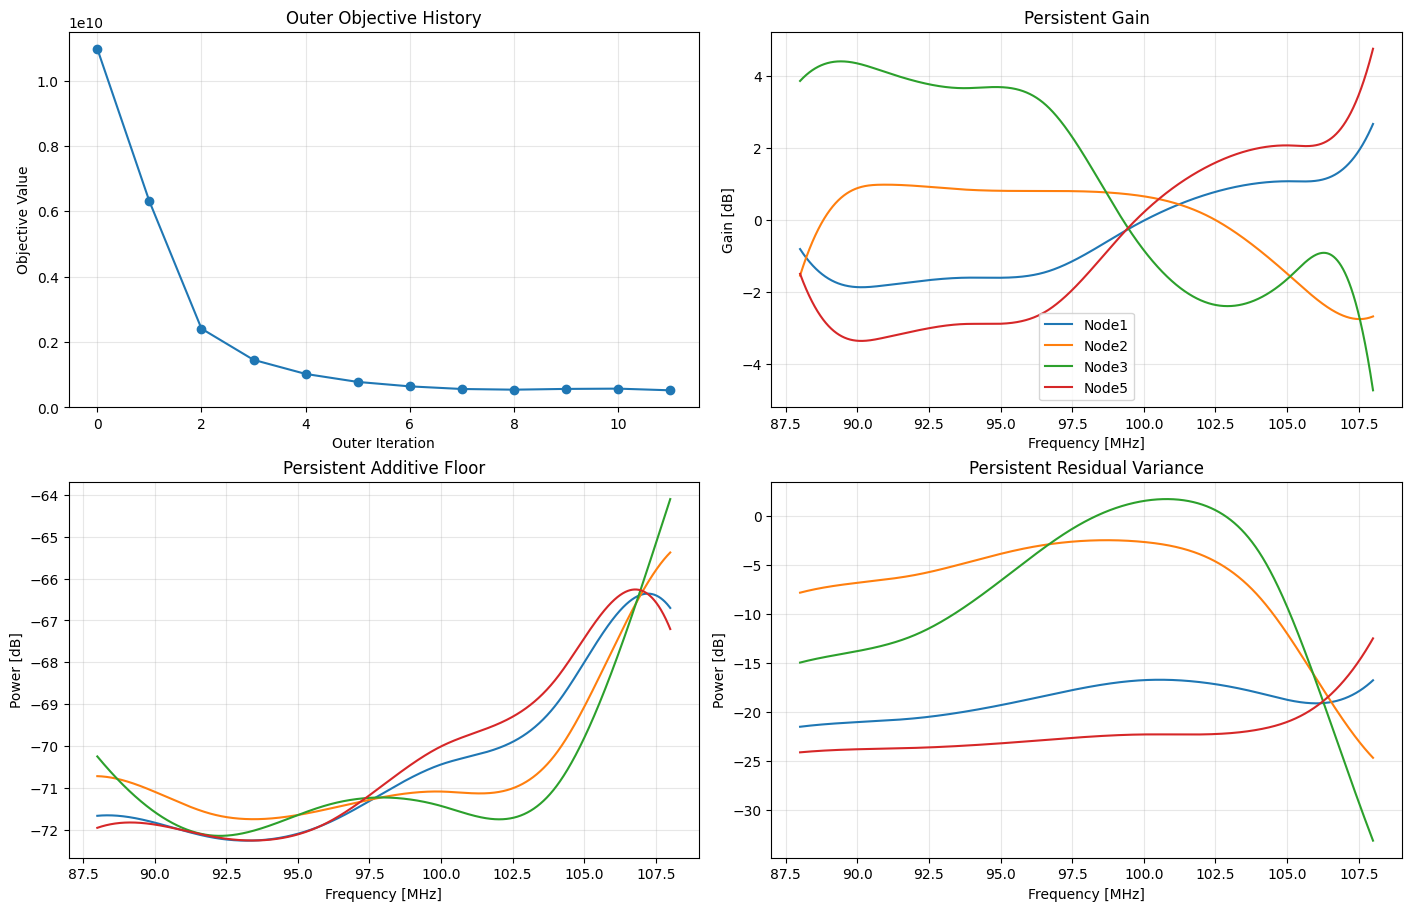

,sensor_id,mean_gain_db,mean_floor_db,mean_variance_db
0,Node1,-0.449612,-70.474236,-18.822403
1,Node2,0.033279,-70.543125,-7.020263
2,Node3,1.133008,-70.826997,-7.999298
3,Node5,-0.716676,-70.275298,-22.145200


In [6]:
inspection_campaign = preparation.prepared_campaigns[0].campaign
frequency_mhz = inspection_campaign.frequency_hz / 1.0e6

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

axes[0, 0].plot(
    range(len(fit_result.result.objective_history)),
    fit_result.result.objective_history,
    marker="o",
)
axes[0, 0].set_title("Outer Objective History")
axes[0, 0].set_xlabel("Outer Iteration")
axes[0, 0].set_ylabel("Objective Value")
axes[0, 0].grid(alpha=0.3)

curve_rows = []
for sensor_id in fit_result.result.sensor_ids:
    curves = evaluate_persistent_calibration(
        result=fit_result.result,
        sensor_id=sensor_id,
        configuration=inspection_campaign.configuration,
        frequency_hz=inspection_campaign.frequency_hz,
    )
    axes[0, 1].plot(frequency_mhz, power_linear_to_db(curves.gain_power), label=sensor_id)
    axes[1, 0].plot(
        frequency_mhz,
        power_linear_to_db(curves.additive_noise_power),
        label=sensor_id,
    )
    axes[1, 1].plot(
        frequency_mhz,
        power_linear_to_db(curves.residual_variance_power2),
        label=sensor_id,
    )
    curve_rows.append(
        {
            "sensor_id": sensor_id,
            "mean_gain_db": float(power_linear_to_db(curves.gain_power).mean()),
            "mean_floor_db": float(power_linear_to_db(curves.additive_noise_power).mean()),
            "mean_variance_db": float(power_linear_to_db(curves.residual_variance_power2).mean()),
        }
    )

axes[0, 1].set_title("Persistent Gain")
axes[0, 1].set_xlabel("Frequency [MHz]")
axes[0, 1].set_ylabel("Gain [dB]")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend(loc="best")

axes[1, 0].set_title("Persistent Additive Floor")
axes[1, 0].set_xlabel("Frequency [MHz]")
axes[1, 0].set_ylabel("Power [dB]")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].set_title("Persistent Residual Variance")
axes[1, 1].set_xlabel("Frequency [MHz]")
axes[1, 1].set_ylabel("Power [dB]")
axes[1, 1].grid(alpha=0.3)

plt.show()

display(pd.DataFrame(curve_rows).sort_values("sensor_id"))

## Hyperparameter Tuning Diagnostics

This section emits comparison-friendly diagnostics for tuning runs. The tables below report:

- the exact fit hyperparameters and workflow/provenance fingerprints stored in the inspected artifact;
- whether the notebook kept the run in staging or promoted it into `models/production/`;
- the outer-iteration objective deltas and optimizer stability indicators;
- per-campaign same-scene RMSE before and after calibration in dB for both training and testing campaigns;
- the persistent-only log-dispersion that `lambda_consistency` regularizes directly;
- the persistent-only mean pairwise frequency correlation that `lambda_correlation` regularizes directly;
- the weighted consistency and correlation contributions, so you can see whether the chosen auxiliary weights are numerically active or effectively zero relative to the selected objective.


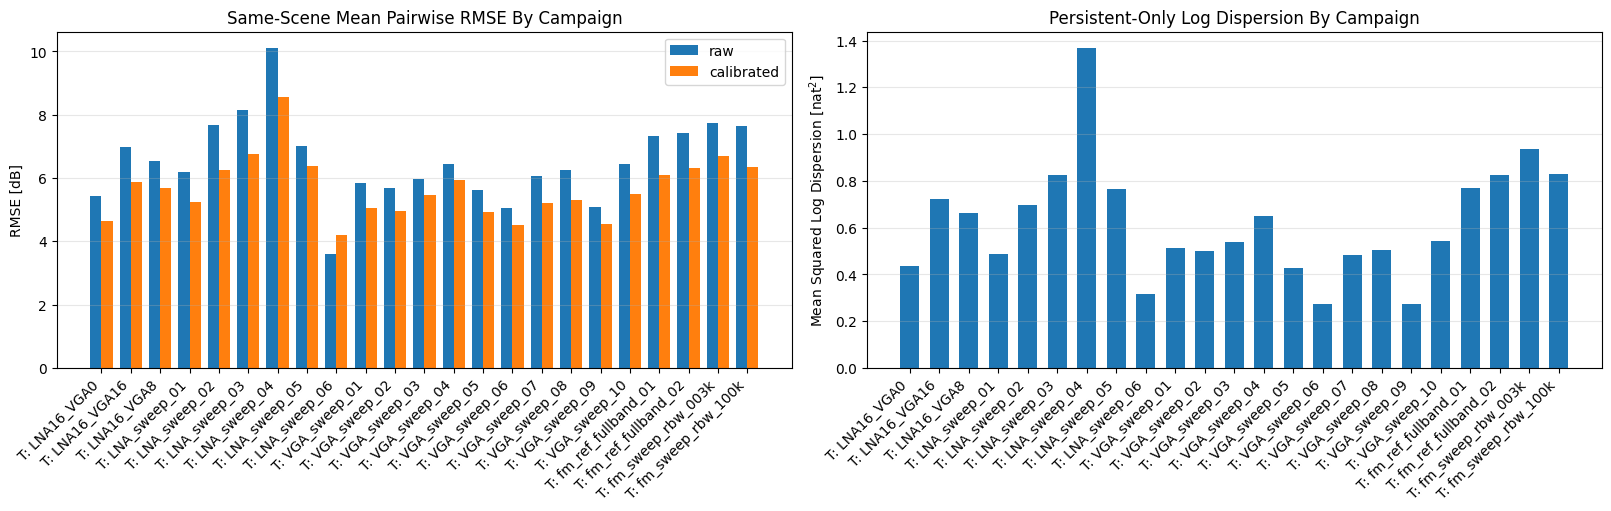

,artifact_dir,promoted_to_production,training_backend,used_gpu,lambda_consistency,lambda_correlation,consistency_log_floor_power,selected_outer_iteration,n_completed_outer_iterations,selected_objective_value,final_objective_value,max_gradient_norm,max_objective_increase_ratio,fit_duration_s,workflow_fingerprint_matches,mean_training_calibrated_rmse_db,mean_training_rmse_improvement_db,mean_training_persistent_log_dispersion_nat2,total_training_persistent_log_dispersion_nat2,training_weighted_consistency_contribution,mean_training_persistent_pairwise_correlation,total_training_correlation_penalty,training_weighted_correlation_contribution,training_consistency_vs_selected_objective,mean_testing_calibrated_rmse_db,mean_testing_rmse_improvement_db,mean_testing_persistent_log_dispersion_nat2,mean_testing_persistent_pairwise_correlation,total_testing_persistent_log_dispersion_nat2,testing_weighted_consistency_contribution,total_testing_correlation_penalty,testing_weighted_correlation_contribution
0,models/.production_staging__hjqcwqei,False,kaggle_cupy_gpu,True,30000.0,100000.0,1.000000e-10,11,12,5.215252e+08,5.215252e+08,4.308083e+09,0.043521,642.163172,True,5.717507,0.847867,0.626546,12.530915,375927.441875,0.876258,2.474847,247484.702443,0.000721,5.394355,0.927868,0.60769,0.90771,1.82307,54692.105239,0.276871,27687.064288


,hyperparameter,value
0,adam_beta1,0.9
1,adam_beta2,0.999
2,adam_epsilon,0.0
3,adaptive_variance_floor_ratio,0.0001
4,consistency_log_floor_power,0.0
5,divergence_tolerance_ratio,10.0
6,early_stopping_patience,5
7,early_stopping_relative_tolerance,0.0001
8,gradient_clip_norm,10.0
9,lambda_consistency,30000.0


,artifact_workflow_config_fingerprint,current_workflow_config_fingerprint,workflow_fingerprint_matches,git_commit,git_dirty,corpus_fingerprint
0,62ae56e5e3f63fad0f3bd52069f6664cf4ff4ca08883cb...,62ae56e5e3f63fad0f3bd52069f6664cf4ff4ca08883cb...,True,39ee7958df07b749ee0f9d657f3a0c2c0b6122de,True,56ddd9074b2d062d85114123c5f71e8eaac140867c7eef...


,outer_iteration_index,outer_iteration_number,objective_value,objective_delta,relative_objective_delta,is_selected_outer_iteration,is_best_so_far
0,0,1,1.097592e+10,NaN,NaN,False,True
1,1,2,6.306891e+09,-4.669026e+09,-0.425388,False,True
2,2,3,2.409015e+09,-3.897876e+09,-0.618035,False,True
3,3,4,1.453606e+09,-9.554085e+08,-0.396597,False,True
4,4,5,1.022699e+09,-4.309069e+08,-0.296440,False,True
5,5,6,7.783314e+08,-2.443678e+08,-0.238944,False,True
6,6,7,6.421036e+08,-1.362278e+08,-0.175025,False,True
7,7,8,5.618011e+08,-8.030247e+07,-0.125062,False,True
8,8,9,5.407934e+08,-2.100768e+07,-0.037393,False,True
9,9,10,5.643294e+08,2.353594e+07,0.043521,False,False


,role,n_campaigns,mean_raw_rmse_db,mean_calibrated_rmse_db,mean_rmse_improvement_db,max_calibrated_rmse_db,mean_persistent_log_dispersion_nat2,mean_persistent_log_rmse_nat,n_ood_campaigns,total_persistent_log_dispersion_nat2,weighted_consistency_contribution,mean_persistent_pairwise_correlation,total_persistent_correlation_penalty,weighted_correlation_contribution
0,testing,3,6.322223,5.394355,0.927868,7.084545,0.607690,0.775239,0,1.823070,54692.105239,0.907710,0.276871,27687.064288
1,training,20,6.565374,5.717507,0.847867,8.680357,0.626546,0.776030,0,12.530915,375927.441875,0.876258,2.474847,247484.702443


,role,campaign_label,center_frequency_mhz,span_mhz,rbw_hz,lna_gain_db,vga_gain_db,antenna_amplifier_enabled,n_sensors,n_records,n_frequencies,mean_pairwise_raw_rmse_db,mean_pairwise_calibrated_rmse_db,mean_pairwise_improvement_db,median_pairwise_calibrated_rmse_db,max_pairwise_calibrated_rmse_db,persistent_log_dispersion_nat2,persistent_log_rmse_nat,persistent_pairwise_correlation,persistent_correlation_penalty,training_campaign_objective_value,configuration_ood,configuration_geometric_ood,overall_ood,out_of_range_feature_names,mahalanobis_distance,mahalanobis_threshold
0,testing,LNA16_VGA0,98.0,20.0,3000.0,16.0,0.0,True,4,28,16384,5.423538,4.647645,0.775893,4.650561,4.827958,0.437498,0.661436,0.906867,0.093133,NaN,False,False,False,-,2.285979,4.298291
1,testing,LNA16_VGA16,98.0,20.0,3000.0,16.0,16.0,True,4,28,16384,6.991025,5.858943,1.132081,5.590094,7.084545,0.722964,0.850273,0.907623,0.092377,NaN,False,False,False,-,0.938362,4.298291
2,testing,LNA16_VGA8,98.0,20.0,3000.0,16.0,8.0,True,4,28,16384,6.552107,5.676477,0.875630,5.689597,5.923216,0.662608,0.814007,0.908640,0.091360,NaN,False,False,False,-,0.934201,4.298291
3,training,LNA_sweep_01,98.0,20.0,10000.0,0.0,16.0,True,3,1,4096,6.202084,5.254842,0.947242,5.254842,5.254842,0.488106,0.698646,0.875293,0.124707,6.322447e+05,False,False,False,-,2.374667,4.298291
4,training,LNA_sweep_02,98.0,20.0,10000.0,8.0,16.0,True,3,4,4096,7.683027,6.261426,1.421601,6.242953,6.369046,0.697109,0.834930,0.863163,0.136837,7.005471e+05,False,False,False,-,1.433513,4.298291
5,training,LNA_sweep_03,98.0,20.0,10000.0,16.0,16.0,True,3,3,4096,8.135808,6.773574,1.362234,6.675292,6.994331,0.826774,0.909271,0.850459,0.149541,2.534510e+06,False,False,False,-,0.738536,4.298291
6,training,LNA_sweep_04,98.0,20.0,10000.0,24.0,16.0,True,3,4,4096,10.118373,8.560728,1.557646,8.551398,8.680357,1.369566,1.170285,0.825288,0.174712,2.301144e+07,False,False,False,-,1.053790,4.298291
7,training,LNA_sweep_05,98.0,20.0,10000.0,32.0,16.0,True,3,7,4096,7.017516,6.393558,0.623957,6.436704,6.709438,0.765348,0.874841,0.843039,0.156961,2.772361e+08,False,False,False,-,1.936511,4.298291
8,training,LNA_sweep_06,98.0,20.0,10000.0,40.0,16.0,True,3,1,4096,3.586035,4.186234,-0.600200,4.186234,4.186234,0.317231,0.563233,0.765256,0.234744,4.285244e+06,False,False,False,-,2.909337,4.298291
9,training,VGA_sweep_01,98.0,20.0,10000.0,16.0,0.0,True,4,4,4096,5.829735,5.050826,0.778909,5.045131,5.100732,0.512121,0.715626,0.864208,0.135792,3.866447e+05,False,False,False,-,2.276371,4.298291


In [7]:
from measurement_calibration import (
    CalibrationCampaign,
    build_cross_node_campaign_animation_data,
    calibrate_sensor_observations,
    prepare_calibration_campaign,
)


def _build_same_scene_campaign_animation_data(
    result: TwoLevelCalibrationResult,
    campaign: CalibrationCampaign,
):
    """Evaluate deployment-time calibration across one same-scene campaign."""

    def calibrate_sensor(
        sensor_id: str,
        observations_power: np.ndarray,
    ):
        """Bind one prepared same-scene campaign to the deployed calibrator."""

        return calibrate_sensor_observations(
            result=result,
            sensor_id=sensor_id,
            configuration=campaign.configuration,
            frequency_hz=campaign.frequency_hz,
            observations_power=observations_power,
        )

    return build_cross_node_campaign_animation_data(
        campaign=campaign,
        calibrate_sensor=calibrate_sensor,
    )


def _persistent_only_log_dispersion(
    result: TwoLevelCalibrationResult,
    campaign: CalibrationCampaign,
    log_floor_power: float,
) -> float:
    """Return the mean persistent-only same-scene log-dispersion for one campaign."""

    transformed_corrected_power_by_sensor = []
    for sensor_id, observations_power in zip(
        campaign.sensor_ids,
        campaign.observations_power,
        strict=True,
    ):
        curves = evaluate_persistent_calibration(
            result=result,
            sensor_id=sensor_id,
            configuration=campaign.configuration,
            frequency_hz=campaign.frequency_hz,
            allow_configuration_ood=True,
        )
        persistent_only_corrected_power = (
            np.maximum(
                observations_power - curves.additive_noise_power[np.newaxis, :],
                0.0,
            )
            / curves.gain_power[np.newaxis, :]
        )
        transformed_corrected_power_by_sensor.append(
            np.log(persistent_only_corrected_power + log_floor_power)
        )

    transformed_corrected_power = np.stack(
        transformed_corrected_power_by_sensor,
        axis=0,
    )
    centered_transformed_power = transformed_corrected_power - np.mean(
        transformed_corrected_power,
        axis=0,
        keepdims=True,
    )
    return float(np.mean(centered_transformed_power**2))


def _persistent_only_pairwise_frequency_correlation(
    result: TwoLevelCalibrationResult,
    campaign: CalibrationCampaign,
    log_floor_power: float,
) -> float:
    """Return the mean persistent-only pairwise frequency correlation for one campaign."""

    transformed_corrected_power_by_sensor = []
    for sensor_id, observations_power in zip(
        campaign.sensor_ids,
        campaign.observations_power,
        strict=True,
    ):
        curves = evaluate_persistent_calibration(
            result=result,
            sensor_id=sensor_id,
            configuration=campaign.configuration,
            frequency_hz=campaign.frequency_hz,
            allow_configuration_ood=True,
        )
        persistent_only_corrected_power = (
            np.maximum(
                observations_power - curves.additive_noise_power[np.newaxis, :],
                0.0,
            )
            / curves.gain_power[np.newaxis, :]
        )
        transformed_corrected_power_by_sensor.append(
            np.log(persistent_only_corrected_power + log_floor_power)
        )

    transformed_corrected_power = np.stack(
        transformed_corrected_power_by_sensor,
        axis=0,
    )
    pairwise_correlations = []
    for acquisition_index in range(transformed_corrected_power.shape[1]):
        transformed_record = transformed_corrected_power[:, acquisition_index, :]
        centered_record = transformed_record - np.mean(
            transformed_record,
            axis=1,
            keepdims=True,
        )
        norms = np.sqrt(np.sum(centered_record**2, axis=1))
        for sensor_index in range(centered_record.shape[0] - 1):
            for other_sensor_index in range(sensor_index + 1, centered_record.shape[0]):
                if norms[sensor_index] <= 1.0e-6 and norms[other_sensor_index] <= 1.0e-6:
                    pairwise_correlations.append(1.0)
                    continue
                pairwise_correlations.append(
                    float(
                        np.dot(
                            centered_record[sensor_index],
                            centered_record[other_sensor_index],
                        )
                        / max(norms[sensor_index], 1.0e-6)
                        / max(norms[other_sensor_index], 1.0e-6)
                    )
                )

    return float(np.mean(pairwise_correlations))


artifact_workflow_fingerprint = loaded_artifact.manifest["provenance"].get(
    "workflow_config_fingerprint"
)
current_workflow_fingerprint = fingerprint_notebook_workflow_config(
    REPO_ROOT / NOTEBOOK_WORKFLOW_CONFIG_DIRNAME
)

fit_config_frame = pd.DataFrame(
    [
        {
            "hyperparameter": parameter,
            "value": value,
        }
        for parameter, value in loaded_artifact.manifest["fit_config"].items()
    ]
).sort_values("hyperparameter", ignore_index=True)

provenance_frame = pd.DataFrame(
    [
        {
            "artifact_workflow_config_fingerprint": artifact_workflow_fingerprint or "-",
            "current_workflow_config_fingerprint": current_workflow_fingerprint,
            "workflow_fingerprint_matches": (
                artifact_workflow_fingerprint == current_workflow_fingerprint
            ),
            "git_commit": loaded_artifact.manifest["provenance"].get("git_commit") or "-",
            "git_dirty": loaded_artifact.manifest["provenance"].get("git_dirty"),
            "corpus_fingerprint": loaded_artifact.manifest["provenance"].get("corpus_fingerprint") or "-",
        }
    ]
)

objective_history = np.asarray(loaded_artifact.result.objective_history, dtype=np.float64)
objective_history_frame = pd.DataFrame(
    {
        "outer_iteration_index": np.arange(objective_history.size, dtype=int),
        "outer_iteration_number": np.arange(1, objective_history.size + 1, dtype=int),
        "objective_value": objective_history,
    }
)
objective_history_frame["objective_delta"] = objective_history_frame[
    "objective_value"
].diff()
objective_history_frame["relative_objective_delta"] = (
    objective_history_frame["objective_delta"]
    / objective_history_frame["objective_value"].shift(1).abs().clip(lower=1.0e-12)
)
objective_history_frame["is_selected_outer_iteration"] = (
    objective_history_frame["outer_iteration_index"]
    == loaded_artifact.result.fit_diagnostics.selected_outer_iteration
)
objective_history_frame["is_best_so_far"] = (
    objective_history_frame["objective_value"]
    == objective_history_frame["objective_value"].cummin()
)

evaluation_campaign_rows = [
    {
        "role": "training",
        "campaign_label": prepared_campaign.campaign_label,
        "campaign": prepared_campaign.campaign,
    }
    for prepared_campaign in preparation.prepared_campaigns
]
evaluation_campaign_rows.extend(
    {
        "role": "testing",
        "campaign_label": campaign_label,
        "campaign": prepare_calibration_campaign(
            campaign_label=campaign_label,
            campaigns_root=CAMPAIGNS_ROOT,
            excluded_sensor_ids=GLOBAL_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN[campaign_label],
            excluded_leading_measurements_per_sensor=(
                EXCLUDED_LEADING_MEASUREMENTS_PER_SENSOR
            ),
        ).campaign,
    }
    for campaign_label in TESTING_CAMPAIGN_LABELS
)
training_campaign_state_by_label = {
    campaign_state.campaign_label: campaign_state
    for campaign_state in loaded_artifact.result.campaign_states
}

campaign_diagnostic_rows = []

# Evaluate the same quantity that is inspected visually during deployment,
# then pair it with the exact persistent-only log-dispersion used by the
# consistency regularizer.
for evaluation_campaign_row in evaluation_campaign_rows:
    role = evaluation_campaign_row["role"]
    campaign_label = evaluation_campaign_row["campaign_label"]
    campaign = evaluation_campaign_row["campaign"]
    animation_data = _build_same_scene_campaign_animation_data(
        result=loaded_artifact.result,
        campaign=campaign,
    )
    raw_pairwise_rmse_db = np.asarray(
        [
            alignment.mean_pairwise_raw_rmse_db
            for alignment in animation_data.record_alignments
        ],
        dtype=np.float64,
    )
    calibrated_pairwise_rmse_db = np.asarray(
        [
            alignment.mean_pairwise_calibrated_rmse_db
            for alignment in animation_data.record_alignments
        ],
        dtype=np.float64,
    )
    trust_diagnostics = evaluate_persistent_calibration(
        result=loaded_artifact.result,
        sensor_id=campaign.sensor_ids[0],
        configuration=campaign.configuration,
        frequency_hz=campaign.frequency_hz,
        allow_configuration_ood=True,
    ).trust_diagnostics
    persistent_log_dispersion_nat2 = _persistent_only_log_dispersion(
        result=loaded_artifact.result,
        campaign=campaign,
        log_floor_power=loaded_artifact.result.fit_config.consistency_log_floor_power,
    )
    persistent_pairwise_correlation = _persistent_only_pairwise_frequency_correlation(
        result=loaded_artifact.result,
        campaign=campaign,
        log_floor_power=loaded_artifact.result.fit_config.consistency_log_floor_power,
    )
    training_campaign_state = training_campaign_state_by_label.get(campaign_label)
    campaign_diagnostic_rows.append(
        {
            "role": role,
            "campaign_label": campaign_label,
            "center_frequency_mhz": float(campaign.configuration.central_frequency_hz / 1.0e6),
            "span_mhz": float(campaign.configuration.span_hz / 1.0e6),
            "rbw_hz": float(campaign.configuration.resolution_bandwidth_hz),
            "lna_gain_db": float(campaign.configuration.lna_gain_db),
            "vga_gain_db": float(campaign.configuration.vga_gain_db),
            "antenna_amplifier_enabled": bool(
                campaign.configuration.antenna_amplifier_enabled
            ),
            "n_sensors": animation_data.n_sensors,
            "n_records": animation_data.n_records,
            "n_frequencies": int(animation_data.frequency_hz.size),
            "mean_pairwise_raw_rmse_db": float(np.mean(raw_pairwise_rmse_db)),
            "mean_pairwise_calibrated_rmse_db": float(
                np.mean(calibrated_pairwise_rmse_db)
            ),
            "mean_pairwise_improvement_db": float(
                np.mean(raw_pairwise_rmse_db)
                - np.mean(calibrated_pairwise_rmse_db)
            ),
            "median_pairwise_calibrated_rmse_db": float(
                np.median(calibrated_pairwise_rmse_db)
            ),
            "max_pairwise_calibrated_rmse_db": float(
                np.max(calibrated_pairwise_rmse_db)
            ),
            "persistent_log_dispersion_nat2": float(persistent_log_dispersion_nat2),
            "persistent_log_rmse_nat": float(
                np.sqrt(persistent_log_dispersion_nat2)
            ),
            "persistent_pairwise_correlation": float(
                persistent_pairwise_correlation
            ),
            "persistent_correlation_penalty": float(
                1.0 - persistent_pairwise_correlation
            ),
            "training_campaign_objective_value": (
                np.nan
                if training_campaign_state is None
                else float(training_campaign_state.objective_value)
            ),
            "configuration_ood": bool(
                trust_diagnostics.configuration_out_of_distribution
            ),
            "configuration_geometric_ood": bool(
                trust_diagnostics.configuration_geometric_out_of_distribution
            ),
            "overall_ood": bool(trust_diagnostics.overall_out_of_distribution),
            "out_of_range_feature_names": (
                ", ".join(trust_diagnostics.out_of_range_feature_names) or "-"
            ),
            "mahalanobis_distance": (
                np.nan
                if trust_diagnostics.configuration_mahalanobis_distance is None
                else float(trust_diagnostics.configuration_mahalanobis_distance)
            ),
            "mahalanobis_threshold": (
                np.nan
                if trust_diagnostics.configuration_mahalanobis_threshold is None
                else float(trust_diagnostics.configuration_mahalanobis_threshold)
            ),
        }
    )

campaign_diagnostics_frame = pd.DataFrame(campaign_diagnostic_rows).sort_values(
    ["role", "campaign_label"],
    ignore_index=True,
)

role_summary_rows = []
for role, role_frame in campaign_diagnostics_frame.groupby("role", sort=False):
    role_summary_rows.append(
        {
            "role": role,
            "n_campaigns": int(len(role_frame)),
            "mean_raw_rmse_db": float(role_frame["mean_pairwise_raw_rmse_db"].mean()),
            "mean_calibrated_rmse_db": float(
                role_frame["mean_pairwise_calibrated_rmse_db"].mean()
            ),
            "mean_rmse_improvement_db": float(
                role_frame["mean_pairwise_improvement_db"].mean()
            ),
            "max_calibrated_rmse_db": float(
                role_frame["max_pairwise_calibrated_rmse_db"].max()
            ),
            "mean_persistent_log_dispersion_nat2": float(
                role_frame["persistent_log_dispersion_nat2"].mean()
            ),
            "mean_persistent_log_rmse_nat": float(
                role_frame["persistent_log_rmse_nat"].mean()
            ),
            "n_ood_campaigns": int(role_frame["overall_ood"].sum()),
            "total_persistent_log_dispersion_nat2": float(
                role_frame["persistent_log_dispersion_nat2"].sum()
            ),
            "weighted_consistency_contribution": float(
                loaded_artifact.result.fit_config.lambda_consistency
                * role_frame["persistent_log_dispersion_nat2"].sum()
            ),
            "mean_persistent_pairwise_correlation": float(
                role_frame["persistent_pairwise_correlation"].mean()
            ),
            "total_persistent_correlation_penalty": float(
                role_frame["persistent_correlation_penalty"].sum()
            ),
            "weighted_correlation_contribution": float(
                loaded_artifact.result.fit_config.lambda_correlation
                * role_frame["persistent_correlation_penalty"].sum()
            ),
        }
    )
role_summary_frame = pd.DataFrame(role_summary_rows)
role_summary_by_role = {
    row["role"]: row
    for row in role_summary_frame.to_dict(orient="records")
}

tuning_run_summary = pd.DataFrame(
    [
        {
            "artifact_dir": str(INSPECTED_ARTIFACT_DIR.relative_to(REPO_ROOT)),
            "promoted_to_production": promoted_to_production,
            "training_backend": TRAINING_BACKEND_INFO.backend_label,
            "used_gpu": TRAINING_BACKEND_INFO.used_gpu,
            "lambda_consistency": loaded_artifact.result.fit_config.lambda_consistency,
            "lambda_correlation": loaded_artifact.result.fit_config.lambda_correlation,
            "consistency_log_floor_power": (
                loaded_artifact.result.fit_config.consistency_log_floor_power
            ),
            "selected_outer_iteration": (
                loaded_artifact.result.fit_diagnostics.selected_outer_iteration
            ),
            "n_completed_outer_iterations": (
                loaded_artifact.result.fit_diagnostics.n_completed_outer_iterations
            ),
            "selected_objective_value": (
                loaded_artifact.result.fit_diagnostics.selected_objective_value
            ),
            "final_objective_value": (
                loaded_artifact.result.fit_diagnostics.final_objective_value
            ),
            "max_gradient_norm": float(
                max(
                    loaded_artifact.result.fit_diagnostics.max_gradient_norm_by_outer_iteration,
                    default=0.0,
                )
            ),
            "max_objective_increase_ratio": (
                loaded_artifact.result.fit_diagnostics.max_objective_increase_ratio
            ),
            "fit_duration_s": loaded_artifact.manifest["extra_summary"]["fit_duration_s"],
            "workflow_fingerprint_matches": (
                artifact_workflow_fingerprint == current_workflow_fingerprint
            ),
            "mean_training_calibrated_rmse_db": float(
                role_summary_by_role["training"]["mean_calibrated_rmse_db"]
            ),
            "mean_training_rmse_improvement_db": float(
                role_summary_by_role["training"]["mean_rmse_improvement_db"]
            ),
            "mean_training_persistent_log_dispersion_nat2": float(
                role_summary_by_role["training"]["mean_persistent_log_dispersion_nat2"]
            ),
            "total_training_persistent_log_dispersion_nat2": float(
                role_summary_by_role["training"]["total_persistent_log_dispersion_nat2"]
            ),
            "training_weighted_consistency_contribution": float(
                role_summary_by_role["training"]["weighted_consistency_contribution"]
            ),
            "mean_training_persistent_pairwise_correlation": float(
                role_summary_by_role["training"]["mean_persistent_pairwise_correlation"]
            ),
            "total_training_correlation_penalty": float(
                role_summary_by_role["training"]["total_persistent_correlation_penalty"]
            ),
            "training_weighted_correlation_contribution": float(
                role_summary_by_role["training"]["weighted_correlation_contribution"]
            ),
            "training_consistency_vs_selected_objective": float(
                role_summary_by_role["training"]["weighted_consistency_contribution"]
                / max(
                    abs(loaded_artifact.result.fit_diagnostics.selected_objective_value),
                    1.0e-12,
                )
            ),
            "mean_testing_calibrated_rmse_db": float(
                role_summary_by_role.get("testing", {}).get(
                    "mean_calibrated_rmse_db",
                    np.nan,
                )
            ),
            "mean_testing_rmse_improvement_db": float(
                role_summary_by_role.get("testing", {}).get(
                    "mean_rmse_improvement_db",
                    np.nan,
                )
            ),
            "mean_testing_persistent_log_dispersion_nat2": float(
                role_summary_by_role.get("testing", {}).get(
                    "mean_persistent_log_dispersion_nat2",
                    np.nan,
                )
            ),
            "mean_testing_persistent_pairwise_correlation": float(
                role_summary_by_role.get("testing", {}).get(
                    "mean_persistent_pairwise_correlation",
                    np.nan,
                )
            ),
            "total_testing_persistent_log_dispersion_nat2": float(
                role_summary_by_role.get("testing", {}).get(
                    "total_persistent_log_dispersion_nat2",
                    np.nan,
                )
            ),
            "testing_weighted_consistency_contribution": float(
                role_summary_by_role.get("testing", {}).get(
                    "weighted_consistency_contribution",
                    np.nan,
                )
            ),
            "total_testing_correlation_penalty": float(
                role_summary_by_role.get("testing", {}).get(
                    "total_persistent_correlation_penalty",
                    np.nan,
                )
            ),
            "testing_weighted_correlation_contribution": float(
                role_summary_by_role.get("testing", {}).get(
                    "weighted_correlation_contribution",
                    np.nan,
                )
            ),
        }
    ]
)

campaign_plot_frame = campaign_diagnostics_frame.copy()
campaign_plot_frame["campaign_role_label"] = (
    campaign_plot_frame["role"].str[0].str.upper()
    + ": "
    + campaign_plot_frame["campaign_label"]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
x = np.arange(len(campaign_plot_frame), dtype=np.float64)
width = 0.38
axes[0].bar(
    x - width / 2.0,
    campaign_plot_frame["mean_pairwise_raw_rmse_db"],
    width=width,
    label="raw",
)
axes[0].bar(
    x + width / 2.0,
    campaign_plot_frame["mean_pairwise_calibrated_rmse_db"],
    width=width,
    label="calibrated",
)
axes[0].set_title("Same-Scene Mean Pairwise RMSE By Campaign")
axes[0].set_ylabel("RMSE [dB]")
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    campaign_plot_frame["campaign_role_label"],
    rotation=45,
    ha="right",
)
axes[0].grid(alpha=0.3, axis="y")
axes[0].legend(loc="best")

axes[1].bar(
    x,
    campaign_plot_frame["persistent_log_dispersion_nat2"],
    width=0.65,
)
axes[1].set_title("Persistent-Only Log Dispersion By Campaign")
axes[1].set_ylabel("Mean Squared Log Dispersion [nat$^2$]")
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    campaign_plot_frame["campaign_role_label"],
    rotation=45,
    ha="right",
)
axes[1].grid(alpha=0.3, axis="y")
plt.show()

display(tuning_run_summary)
display(fit_config_frame)
display(provenance_frame)
display(objective_history_frame)
display(role_summary_frame)
display(campaign_diagnostics_frame)
